# Buổi 8 — Notebook 2: Mô hình KNN

**Kiến thức nền:**  
KNN phân loại một điểm mới bằng cách xem **k điểm huấn luyện gần nhất** và bỏ phiếu theo đa số.

- KNN dùng **khoảng cách Euclidean** → nhạy cảm với tỉ lệ đặc trưng → **bắt buộc chuẩn hóa**.
- Siêu tham số `k`: nhỏ = overfitting, lớn = underfitting.

**Việc của bạn:** Hoàn thiện các hàm trong `src/preprocessing.py` và `src/knn.py`.

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from src import preprocessing, knn

## 1. Tải dữ liệu

In [2]:
wine = load_wine()
X, y = wine.data, wine.target
feature_names = wine.feature_names
class_names   = wine.target_names

print(f'X shape: {X.shape}  |  Classes: {class_names}')

X shape: (178, 13)  |  Classes: ['class_0' 'class_1' 'class_2']


## 2. Chia tập huấn luyện / kiểm tra

**Hàm cần hoàn thiện:** `preprocessing.chia_train_test()`

In [3]:
X_train, X_test, y_train, y_test = preprocessing.chia_train_test(X, y)

print(f'Tập huấn luyện : {X_train.shape[0]} mẫu')
print(f'Tập kiểm tra   : {X_test.shape[0]} mẫu')

Tập huấn luyện : 142 mẫu
Tập kiểm tra   : 36 mẫu


## 3. Chuẩn hóa đặc trưng

**Hàm cần hoàn thiện:** `preprocessing.chuan_hoa()`

> ⚠️ Fit scaler **chỉ trên X_train**. Nếu fit cả X_test → data leakage.

In [4]:
scaler, X_train_sc, X_test_sc = preprocessing.chuan_hoa(X_train, X_test)

print(f'Trung bình đặc trưng 1 (train scaled): {X_train_sc[:, 0].mean():.4f}')  # ≈ 0
print(f'Std đặc trưng 1      (train scaled): {X_train_sc[:, 0].std():.4f}')    # ≈ 1

Trung bình đặc trưng 1 (train scaled): 0.0000
Std đặc trưng 1      (train scaled): 1.0000


## 4. Tìm k tối ưu (Elbow Method)

**Hàm cần hoàn thiện:** `knn.tim_k_tot_nhat()`

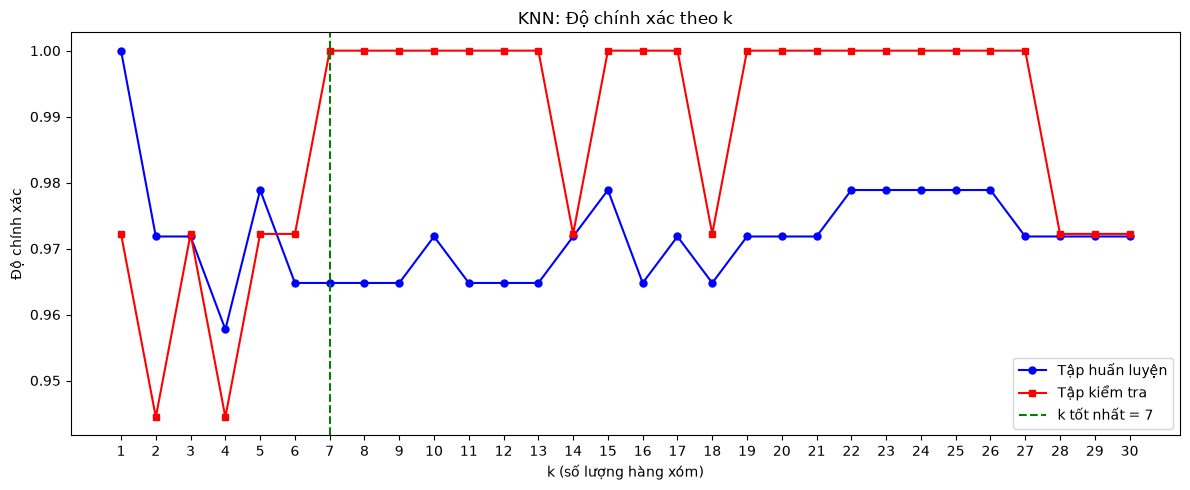


k tốt nhất = 7  |  Độ chính xác test = 1.0000


In [5]:
k_tot_nhat, ls_train, ls_test = knn.tim_k_tot_nhat(
    X_train_sc, X_test_sc, y_train, y_test, k_max=30
)
print(f'\nk tốt nhất = {k_tot_nhat}  |  Độ chính xác test = {max(ls_test):.4f}')

> **Câu hỏi 1:** Khi k tăng lên, độ chính xác train thay đổi thế nào? Đây là dấu hiệu của overfitting hay underfitting?

**Đáp án 1:**  
- k=1: train accuracy = **100%** — mô hình nhớ thuộc lòng từng điểm huấn luyện (mỗi điểm là "hàng xóm gần nhất" của chính nó).  
- k=30: train accuracy ≈ **97.2%** — mô hình tổng quát hóa hơn, bỏ qua nhiễu hơn.  

Khi k nhỏ (đặc biệt k=1): **overfitting** — mô hình quá khớp với training data, kém tổng quát.  
Khi k lớn dần: **underfitting** có thể xảy ra — "bầu cử" từ quá nhiều hàng xóm làm mờ ranh giới.  
**k tốt nhất = 7** là điểm cân bằng giữa hai thái cực.

## 5. Huấn luyện mô hình KNN cuối cùng

**Hàm cần hoàn thiện:** `knn.huan_luyen_knn()`

In [6]:
mo_hinh_knn = knn.huan_luyen_knn(X_train_sc, y_train, k=k_tot_nhat)
print(f'Mô hình: {mo_hinh_knn}')

Mô hình: KNeighborsClassifier(n_neighbors=7)


## 6. Đánh giá mô hình KNN

**Hàm cần hoàn thiện:** `knn.danh_gia_mo_hinh()`

=== Báo cáo phân loại — KNN (k=7) ===
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



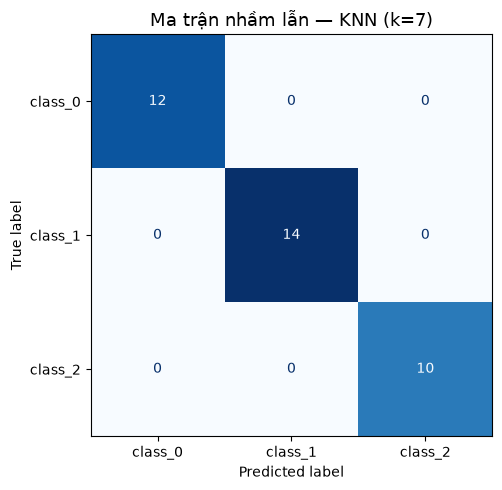


Độ chính xác: 1.0000


In [7]:
ket_qua_knn = knn.danh_gia_mo_hinh(
    mo_hinh_knn, X_test_sc, y_test,
    class_names=class_names,
    tieu_de=f'KNN (k={k_tot_nhat})'
)
print(f'\nĐộ chính xác: {ket_qua_knn["do_chinh_xac"]:.4f}')

## 7. Kiểm định chéo 5-fold

In [8]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler as SS

X_all_sc = SS().fit_transform(X)

diem_cv_knn = knn.kiem_dinh_cheo(
    KNeighborsClassifier(n_neighbors=k_tot_nhat),
    X_all_sc, y, cv=5
)

Điểm CV (5-fold) : [0.9444 0.9444 0.9722 1.     0.9714]
Trung bình           : 0.9665
Độ lệch chuẩn        : 0.0207


> **Câu hỏi 2:** So sánh CV mean với test accuracy. Sự khác biệt lớn thì có vấn đề gì?

**Đáp án 2:**  
- Test accuracy (tập 36 mẫu): **100.0%**  
- CV mean (5-fold, 178 mẫu): **96.65%** ± 2.07%  

Test accuracy cao hơn CV ~3.5% — không đáng lo ngại vì tập test chỉ có 36 mẫu và có thể may mắn được phân chia "dễ". CV đánh giá trên toàn bộ 178 mẫu với 5 lần chia khác nhau nên **tin cậy hơn test accuracy đơn lẻ**.  

**Nếu sự khác biệt lớn (> 10%):**  
- Test acc >> CV mean → test set quá dễ, hoặc có data leakage.  
- Test acc << CV mean → test set không đại diện, hoặc mô hình overfit trên fold cụ thể.  

**Kết luận:** CV std = 0.0207 (nhỏ) → mô hình KNN ổn định, đáng tin cậy.

---
*Tiếp theo: `03_DecisionTree.ipynb`*